In [ ]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(sys.path)


In [1]:
### LIVER DATA

In [1]:
import scanpy as sc
adata = sc.read_loom("/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/liver_time.loom")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
# For reference
adata_orig = adata

In [3]:
##  Analysis of aData object

In [3]:
# Basic Structure and Dimensions
print("adata.shape")
print(adata.shape)

print("adata.n_obs") 
print(adata.n_obs)    # number cells? 
 
print("adata.n_vars") 
print(adata.n_vars)   # annotated 

adata.shape
(7212, 14811)
adata.n_obs
7212
adata.n_vars
14811


In [4]:
# Cell-level Annotations
print("adata.obs.head()")
print(adata.obs.head())
print("adata.obs.columns")
print(adata.obs.columns)
print("adata.obs['seurat_clusters'].value_counts()")
print(adata.obs['seurat_clusters'].value_counts())

adata.obs.head()
        RNA_snn_res.0.8  nCount_RNA  nFeature_RNA  orig.ident  percent.mt rep  \
CellID                                                                          
ZT00B1                3      3287.0          1279           1   15.150593   B   
ZT00B4                7      1397.0           646           1   13.242663   B   
ZT00B5                7      1293.0           615           1   13.689095   B   
ZT00B6                3      1339.0           606           1   21.657954   B   
ZT00B7                3      1712.0           736           1   18.574766   B   

        seurat_clusters time  zonation1  
CellID                                   
ZT00B1                3  T00   0.285488  
ZT00B4                7  T00   0.539859  
ZT00B5                7  T00   0.485066  
ZT00B6                3  T00   0.566012  
ZT00B7                3  T00   0.437602  
adata.obs.columns
Index(['RNA_snn_res.0.8', 'nCount_RNA', 'nFeature_RNA', 'orig.ident',
       'percent.mt', 'rep', 'seur

In [5]:
# NOTES: 
# - There exists only `orig.ident` value (perhaps all liver cells came from the same sample?)
print("set(adata.obs['orig.ident'])")
print(set(adata.obs["orig.ident"]))
print("set(adata.obs['rep'])")
print(set(adata.obs["rep"]))
print("set(adata.obs['time'))")
print(set(adata.obs["time"]))    # hmmm, number of hours after fasting begun? 
print("adata.obs['zonation1') - [ min, max ]")
print(f"adata.obs['zonation1']: [{min(adata.obs['zonation1'])}, {max(adata.obs['zonation1'])}]")    # hmmm, number of hours after fasting begun? 

set(adata.obs['orig.ident'])
{1}
set(adata.obs['rep'])
{np.str_('B')}
set(adata.obs['time'))
{np.str_('T06'), np.str_('T18'), np.str_('T00'), np.str_('T12')}
adata.obs['zonation1') - [ min, max ]
adata.obs['zonation1']: [-0.030190523673301217, 1.2594117949706558]


In [6]:
# Gene-level annotations
print("adata.var.head()") 
print(adata.var.head())
print("adata.var.columns")
print(adata.var.columns) 
print("adata.var.index") 
print(adata.var.index)

adata.var.head()
Empty DataFrame
Columns: []
Index: [0610007p14rik, 0610009b22rik, 0610009l18rik, 0610009o20rik, 0610010f05rik]
adata.var.columns
Index([], dtype='object')
adata.var.index
Index(['0610007p14rik', '0610009b22rik', '0610009l18rik', '0610009o20rik',
       '0610010f05rik', '0610010k14rik', '0610011f06rik', '0610012g03rik',
       '0610025j13rik', '0610030e20rik',
       ...
       'mt-co2', 'mt-co3', 'mt-cytb', 'mt-nd1', 'mt-nd2', 'mt-nd3', 'mt-nd4',
       'mt-nd4l', 'mt-nd5', 'mt-nd6'],
      dtype='object', name='Gene', length=14811)


In [7]:
# Keeping track of all genes associated with the `liver.time` dataset
"""
with open("liver_time_genes.txt", "w") as f:
    for gene in adata.var.index:
        f.write(str(gene) + "\n")
"""

'\nwith open("liver_time_genes.txt", "w") as f:\n    for gene in adata.var.index:\n        f.write(str(gene) + "\n")\n'

In [8]:
# Expression-matrices`
print("adata.X") 
print(adata.X) 
print("adata.layers")  
print(adata) # 1. Exploratory Data Analysis: UMAPs of the raw data based on all different factors incorporated togetherlayers)
print("adata.raw") 
print(adata.raw)

adata.X
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6760288 stored elements and shape (7212, 14811)>
  Coords	Values
  (0, 7)	1.39681077003479
  (0, 20)	1.39681077003479
  (0, 25)	1.957919955253601
  (0, 27)	1.39681077003479
  (0, 41)	1.39681077003479
  (0, 58)	1.39681077003479
  (0, 59)	1.39681077003479
  (0, 80)	1.39681077003479
  (0, 143)	1.39681077003479
  (0, 152)	1.39681077003479
  (0, 155)	1.957919955253601
  (0, 160)	1.39681077003479
  (0, 169)	2.5778770446777344
  (0, 210)	1.39681077003479
  (0, 216)	1.39681077003479
  (0, 222)	1.39681077003479
  (0, 229)	1.39681077003479
  (0, 237)	1.39681077003479
  (0, 268)	1.957919955253601
  (0, 298)	1.39681077003479
  (0, 301)	1.39681077003479
  (0, 363)	1.39681077003479
  (0, 437)	1.39681077003479
  (0, 463)	1.39681077003479
  (0, 474)	1.39681077003479
  :	:
  (7211, 14422)	1.537361979484558
  (7211, 14446)	1.537361979484558
  (7211, 14471)	1.537361979484558
  (7211, 14475)	2.481308698654175
  (7211, 14572)	1.537361979

## 1. Exploratory Data Analysis: UMAPs of the raw data based on all different factors incorporated together

In [9]:
import scanpy as sc

sc.pp.normalize_total(adata, target_sum=1e4)   # normalize counts per cell (NB: `target_sum` could be tinkered with) 
sc.pp.log1p(adata)                             # log-transform
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_hv = adata[:, adata.var['highly_variable']] # select for only those genes that explain variance between cells

sc.pp.scale(adata_hv, max_value=10)
sc.tl.pca(adata_hv, svd_solver='arpack')
sc.pp.neighbors(adata_hv, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_hv)   # computes UMAP and saves in adata.obsm['X_umap']

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


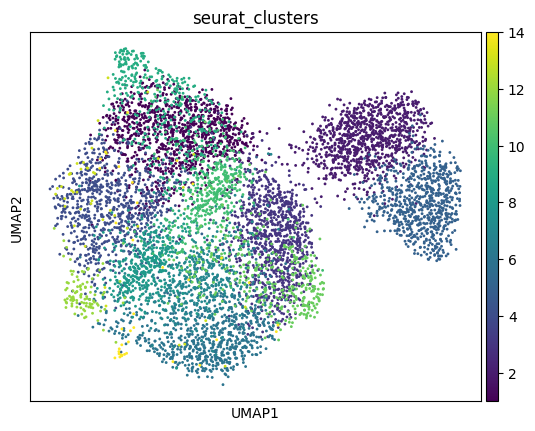

In [10]:
sc.pl.umap(adata_hv, color='seurat_clusters')

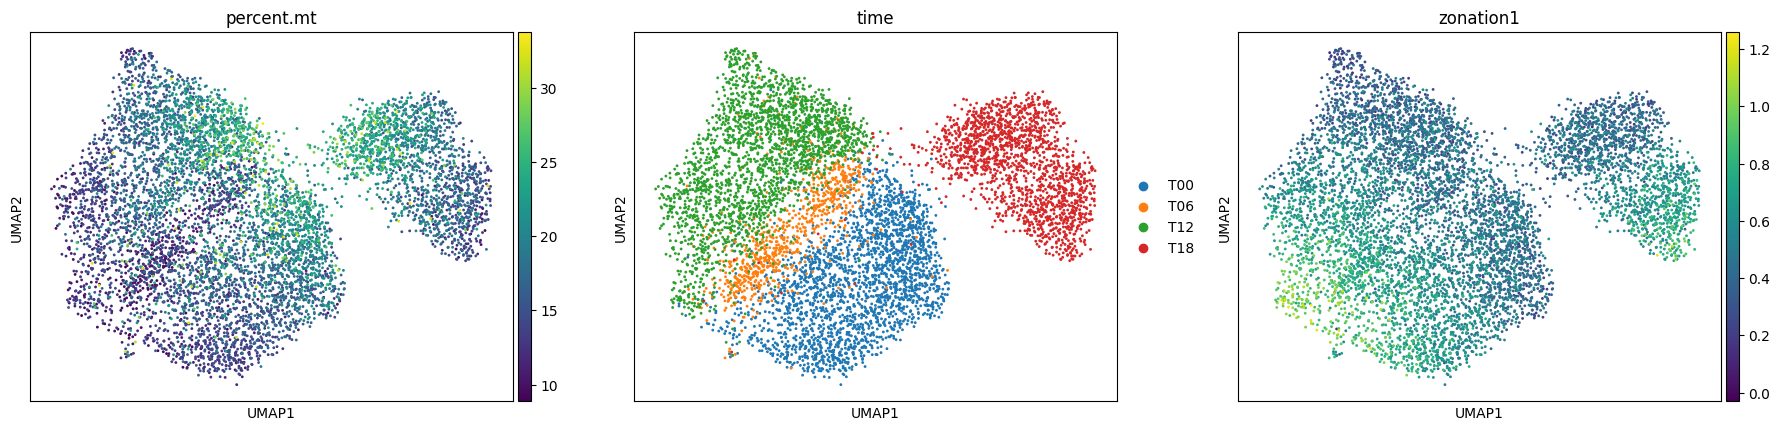

In [12]:
sc.pl.umap(adata_hv, color=['percent.mt', 'time', 'zonation1'])

## 2. Reproducing zonation and time-based signals in the original data using CellUntangler

In [11]:
import sys as sys

print(sys.path)

# If running notebook outside of scrna_mvae directory, add it to the path
sys.path.append('/content/CellUntangler/')
print(sys.version)

['/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/venvs/CellUntangler/lib/python3.11/site-packages']
3.11.12 (main, Apr  8 2025, 14:15:29) [Clang 16.0.0 (clang-1600.0.26.6)]


In [12]:
import os

import torch

from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
import numpy as np

import pandas as pd
import scanpy as sc

In [ ]:
# adata has already been loaded!

In [13]:
zonation_genes_mouse_path = "/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/CellUntangler/genes/zonation_genes_mouse.tsv"
zonation_genes_mouse = pd.read_csv(zonation_genes_mouse_path, header=None, sep="\t")

#### Rearrange genes so zonation genns are placed first

In [14]:
adata = adata_hv

In [15]:
# Pre-processing
adata.var["gene_symbols"] = adata.var.index

In [16]:
# Genes involved with the cell cycle present in adata
contained_genes = adata.var["gene_symbols"].isin(zonation_genes_mouse[0])
print(f"Number of zonation genes present in adata: {np.sum(contained_genes)}")
zonation_gene_indices = np.where(contained_genes)[0]
non_zonation_gene_indices = np.where(~contained_genes)[0]
rearranged_indices = np.hstack((zonation_gene_indices, non_zonation_gene_indices))
adata = adata[:, rearranged_indices]
adata.uns["new_gene_ordering"] = rearranged_indices

Number of zonation genes present in adata: 9


/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_8565/1096378507.py:8: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices


#### Set up configuration for CellUntangler model

In [19]:
from src.celluntangler.models.get_config import get_config

In [20]:
config = get_config()

In [21]:
config.model_name = "e2, e10" 

In [22]:
config.seed = 68715

In [23]:
config.init = "custom" # keep same as HELA dataset - TODO: fully understand the 
                       # training process and how CellUntangler initializes component weights

#### Create training and test datasets

In [24]:
x = adata.X.astype(np.double)   # NB: code is coupled to adata.X currently being a ndarray, which wouldn't 
                                            #     necessarily be true when working with adata_orig
                                # CHANGE - remove np.matrix wrapper
batch = (np.zeros((x.shape[0], 1)) * -1).astype(np.int64)
# y holds the batch vector for the dataset
y = batch

In [23]:
np.unique(batch)

array([0])

In [24]:
x.shape

(7212, 2363)

In [25]:
x.device

'cpu'

In [25]:
# Create the dataset and create (only?) training dataset loader
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 2363
dataset.in_dim = 2363
Dataset seed: 68715


#### Create mask used to separate x into different component that are used when training the model

In [26]:
# Q: Are vars here the genes that explain the majority of variance between liver cell RNA expression? 
mask_zonation = np.zeros(adata.n_vars)    
mask_zonation[adata.var["gene_symbols"].isin(zonation_genes_mouse[0])] = 1

mask_other = np.ones(adata.n_vars)
mask_other[adata.var["gene_symbols"].isin(zonation_genes_mouse[0])] = 0

mask = torch.tensor([mask_zonation, mask_other])

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_2913/1397972723.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  mask = torch.tensor([mask_zonation, mask_other])


In [27]:
# Sanity Check  
# EXPECT: 
# - First tensor is 1s at beginning, 0s at ending 
# - Second tensor is 0s at beginnning, 1s at ending 
for row in mask:
  print(row)
  print(torch.sum(row).item())

tensor([1., 1., 1.,  ..., 0., 0., 0.], dtype=torch.float64)
9.0
tensor([0., 0., 0.,  ..., 1., 1., 1.], dtype=torch.float64)
2354.0


#### Train CellUntangler

In [28]:
torch.set_default_dtype(torch.float64)

In [29]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [30]:
# The path to save the intermediate embeddings to
epoch_embeddings_save_path = "./experiments/liver_zonation_repro"
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)]
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

In [31]:
print(x.dtype, y.dtype)

float64 int64


In [32]:
model_name = config.model_name
components = utils.parse_components(model_name, config.fixed_curvature)
print(components)
print(config.h_dim)

if config.seed:
    print(config.seed)
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)
    np.random.default_rng(config.seed)

model_name = config.model_name
components = utils.parse_components(model_name, config.fixed_curvature)
# =====
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config,
              component_subspaces=None
                  ).to(config.device)
trainer = Trainer(model)

import inspect 
print(inspect.getsource(trainer.train_epochs))
print(model.device)

[EuclideanComponent(R^2), EuclideanComponent(R^10)]
32
68715
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
EuclideanComponent(R^2)
    def train_epochs(self,
                       optimizer: Any,
                       train_data: DataLoader,
                       betas: Sequence[float],
                       likelihood_n: int = 500,
                       max_epochs: int = 1000,
                       visualize_information = None
                       ) -> Dict[int, EpochStats]:
        """
        optimizer: The optimizer.
        train_data: The data loader for loading the data.
        betas: Weights to specify the strength of the KL-divergence. The same beta is used for each latent component.
        likelihood_n: How many samples to use to perform Monte Carlo integration to compute the log-likelihood.
        max_epochs: The number 

In [33]:
print(model._forward_hooks)
print(model._forward_pre_hooks)

OrderedDict()
OrderedDict()


In [ ]:
if config.seed:
    print(config.seed)
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)
    np.random.default_rng(config.seed)

model_name = config.model_name
components = utils.parse_components(model_name, config.fixed_curvature)
# =====
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config,
              component_subspaces=None
                  ).to(config.device)
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)

print("optimizer")
print(optimizer)
print("train_loader")
print(train_loader)
print("betas")
print(betas)

trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                           visualize_information=visualize_information)
"""
                           """

68715
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
EuclideanComponent(R^2)
optimizer
CurvatureOptimizer (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)
train_loader
betas
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

In [ ]:
# IF we reshaped the input so that it mathced that of the cell cycle VAE, would this fix the issue???? 

In [ ]:
%debug

In [ ]:
embeddings_save_path = "./experiments/liver_zonation_repro"
a = trainer.model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'), a[4].detach().to(torch.device("cpu")).numpy())

In [ ]:
# Q: What does the gene expression matrix end up being used for?
gene_expression_matrix_path = "./experiments/liver_zonation_repro"

In [ ]:
import torch.nn as nn
# Encode the batch vector which must also be passed to the decoder
batch = nn.functional.one_hot(torch.tensor(y[:,0]), 1).to(config.device)

library_size = torch.sum(torch.tensor(x), dim=1).to(config.device)

In [ ]:
# To enhance zonation, mask the non-zonation latent representation and pass it to the decoder
# The latent representations have a dimension of 12 (2 dimensions for zonation + 10 dimensions for non-zonation)
z1_mask = torch.zeros(12, device=config.device)
z1_mask[0:2] = 1

z_params = a[4].detach()
x_z1_params_mu = trainer.model.decode(z_params*z1_mask, batch)[0]
x_z1_params_mu = x_z1_params_mu * library_size[:, None] 
# Q: Why does the library_size (RNA expression of each cell (?)) need to be considered 
#    when re-deriving the latent variable values of z1? 
np.savetxt(os.path.join(gene_expression_matrix_path,"x_z1_params_mu.txt"), x_z1_params_mu.detach().to(torch.device("cpu")).numpy())

In [ ]:
# To filter for zonation, mask the zonation latent representation and pass it to the decoder
z2_mask = torch.zeros(12, device=config.device)
z2_mask[2:] = 1

z_params = a[4].detach()
x_z2_params_mu = trainer.model.decode(z_params*z2_mask, batch)[0]
x_z2_params_mu = x_z2_params_mu * library_size[:, None]
np.savetxt(os.path.join(gene_expression_matrix_path,"x_z2_params_mu.txt"), x_z2_params_mu.detach().to(torch.device("cpu")).numpy())

#### Evaluate and Analyze Embeddings

In [17]:
import matplotlib.pyplot as plt

from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, compute_umap

In [18]:
embeddings_save_path = "./experiments/liver_zonation_repro/oct_6"
model_name = "e2, e10"
# Load in the embeddings
# Q: What does "v63" mean in the context of the below? 
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'))

In [19]:
embeddings

array([[-6.26882375e-02,  4.15899817e-03, -3.89413734e-02, ...,
         8.27718875e-03, -1.20444976e-03, -4.41150127e-03],
       [-5.85523629e-01,  4.02100141e-03,  7.85161668e-01, ...,
         1.75882136e-02, -6.17995997e-03, -1.60814372e-02],
       [-1.67598353e+00,  1.45466562e-02,  5.97405364e-01, ...,
         1.81052276e-02, -4.13021985e-03, -1.68690948e-02],
       ...,
       [-9.60099215e-01,  8.31492060e-03,  2.63319845e-01, ...,
         1.74478655e-02,  6.28639986e-03, -8.99514823e-03],
       [-7.44783152e-01,  5.45689098e-03,  8.91169340e-01, ...,
         1.09502510e-02, -1.78360400e-03, -1.00482695e-02],
       [-7.78604785e-01,  7.33733433e-03,  4.38675169e-01, ...,
         1.66928357e-02,  2.31560425e-03, -7.52414736e-03]],
      shape=(7212, 12))

In [20]:
# Returns a dictionary where the keys are of the format componenti_subspace
# E.g., e2, e10 would result in keys of component1_e2 and component2_e10
# The values are the corresponding embeddings
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

e2 2
e10 10


In [18]:
component_embeddings

{'component1_e2': array([[-0.06268824,  0.004159  ],
        [-0.58552363,  0.004021  ],
        [-1.67598353,  0.01454666],
        ...,
        [-0.96009922,  0.00831492],
        [-0.74478315,  0.00545689],
        [-0.77860478,  0.00733733]], shape=(7212, 2)),
 'component2_e10': array([[-0.03894137,  0.00274753,  0.01237631, ...,  0.00827719,
         -0.00120445, -0.0044115 ],
        [ 0.78516167, -0.00511617,  0.01376458, ...,  0.01758821,
         -0.00617996, -0.01608144],
        [ 0.59740536, -0.00523309,  0.00997876, ...,  0.01810523,
         -0.00413022, -0.01686909],
        ...,
        [ 0.26331984,  0.00386435,  0.00646384, ...,  0.01744787,
          0.0062864 , -0.00899515],
        [ 0.89116934,  0.00428178,  0.00953968, ...,  0.01095025,
         -0.0017836 , -0.01004827],
        [ 0.43867517,  0.00460109,  0.0060022 , ...,  0.01669284,
          0.0023156 , -0.00752415]], shape=(7212, 10))}

In [19]:
adata.obsm["component1_e2"]

array([[-0.06268824,  0.004159  ],
       [-0.58552363,  0.004021  ],
       [-1.67598353,  0.01454666],
       ...,
       [-0.96009922,  0.00831492],
       [-0.74478315,  0.00545689],
       [-0.77860478,  0.00733733]], shape=(7212, 2))

In [21]:
adata.obsm["component2_e10"]

array([[-0.03894137,  0.00274753,  0.01237631, ...,  0.00827719,
        -0.00120445, -0.0044115 ],
       [ 0.78516167, -0.00511617,  0.01376458, ...,  0.01758821,
        -0.00617996, -0.01608144],
       [ 0.59740536, -0.00523309,  0.00997876, ...,  0.01810523,
        -0.00413022, -0.01686909],
       ...,
       [ 0.26331984,  0.00386435,  0.00646384, ...,  0.01744787,
         0.0062864 , -0.00899515],
       [ 0.89116934,  0.00428178,  0.00953968, ...,  0.01095025,
        -0.0017836 , -0.01004827],
       [ 0.43867517,  0.00460109,  0.0060022 , ...,  0.01669284,
         0.0023156 , -0.00752415]], shape=(7212, 10))

In [21]:
adata.obsm["component2_e10"].shape

(7212, 10)

In [22]:
embeddings.shape

(7212, 12)

In [23]:
embeddings[:,1].shape

(7212,)

#### Mutual Information Analysis

#### Global View of Mutual Information of all Embeddings Between Space and Time

In [24]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
zonation1_vals = adata.obs['zonation1'].to_numpy()

In [26]:
def time_string_to_num(s):
    return int(s[1:])
time_vals = []

for time_str in adata.obs['time'].to_numpy(): 
    time_vals.append(time_string_to_num(time_str))
time_vals = np.array(time_vals)

In [28]:
zonation1_vals.shape

(7212,)

In [29]:
embeddings[:,1].shape

(7212,)

In [32]:
mi_zonation = np.zeros(embeddings.shape[-1])
for dim in range(embeddings.shape[-1]):
    mi_zonation[dim] = mutual_info_regression(embeddings[:,dim].reshape(-1, 1), zonation1_vals.reshape(-1,1))

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_8565/1649572514.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mi_zonation[dim] = mutual_info_regression(embeddings[:,dim].reshape(-1, 1), zonation1_vals.reshape(-1,1))
/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the

In [34]:
mi_time = np.zeros(embeddings.shape[-1])
for dim in range(embeddings.shape[-1]):
    mi_time[dim] = mutual_info_classif(embeddings[:,dim].reshape(-1,1), time_vals.reshape(-1,1))

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_8565/3902988197.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mi_time[dim] = mutual_info_classif(embeddings[:,dim].reshape(-1,1), time_vals.reshape(-1,1))
/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y t

In [36]:
M = np.vstack((mi_zonation, mi_time))
N_dimensions = 12
df = pd.DataFrame(M, 
                  index=["Zonation1", "Time Fasted"], 
                  columns=np.arange(1, N_dimensions+1))
print(df)

                   1         2         3         4         5         6   \
Zonation1    0.341256  0.185254  0.047395  0.028165  0.017228  0.007827   
Time Fasted  0.028510  0.047506  0.018630  0.251071  0.441638  0.996491   

                   7         8         9         10        11        12  
Zonation1    0.001253  0.013141  0.019580  0.000000  0.038474  0.005053  
Time Fasted  0.184779  0.212290  0.055929  0.224676  0.304938  0.149418  


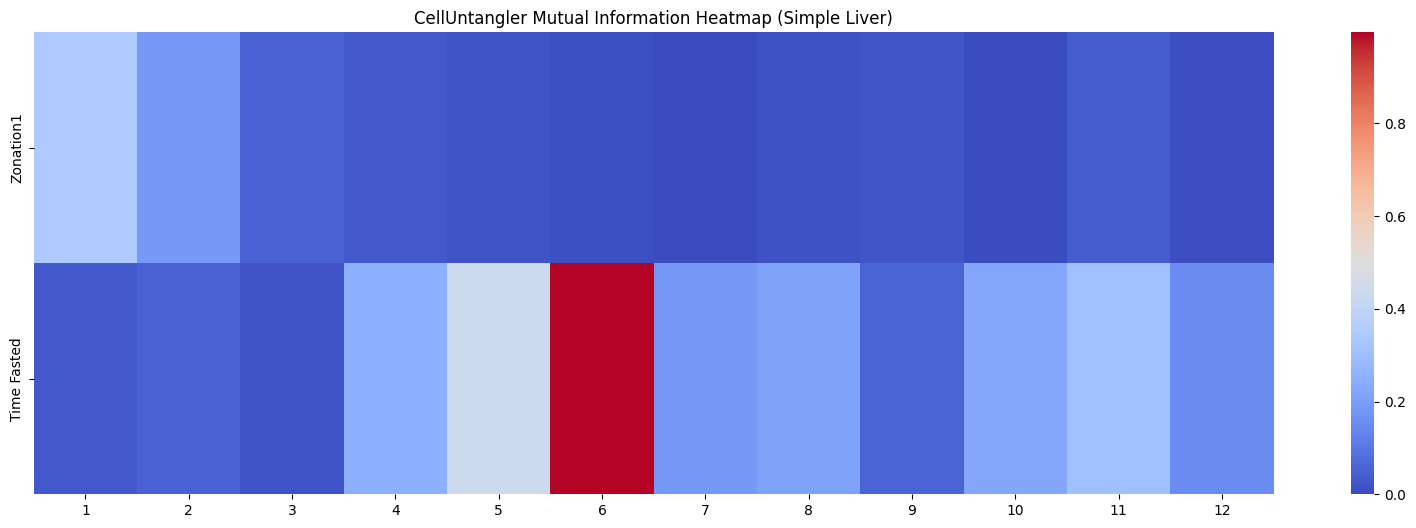

In [37]:
plt.figure(figsize=(20, 6))
sns.heatmap(df, annot=False, cmap="coolwarm")
plt.title("CellUntangler Mutual Information Heatmap (Simple Liver)")
plt.show()

#### Intra-Subspace Mutual Information

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

def mutual_information_matrix(X):
    """
    Compute pairwise mutual information between columns of X.
    Returns a (n_features x n_features) numpy array.
    """
    n_features = X.shape[1]
    mi_matrix = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            if i != j:
                mi = mutual_info_regression(X[:, [i]], X[:, j])[0]
                mi_matrix[i, j] = mi
    return mi_matrix


def plot_mi_matrix(mi_matrix, title, dim_ofst = 0):
    """
    Plot MI matrix as a heatmap.
    """
    df = pd.DataFrame(mi_matrix,
                      columns=[f"Dim {i+1+dim_ofst}" for i in range(mi_matrix.shape[1])],
                      index=[f"Dim {i+1+dim_ofst}" for i in range(mi_matrix.shape[1])])

    plt.figure(figsize=(20, 6))
    sns.heatmap(df, annot=False, cmap="coolwarm")
    plt.title(title)
    plt.show()

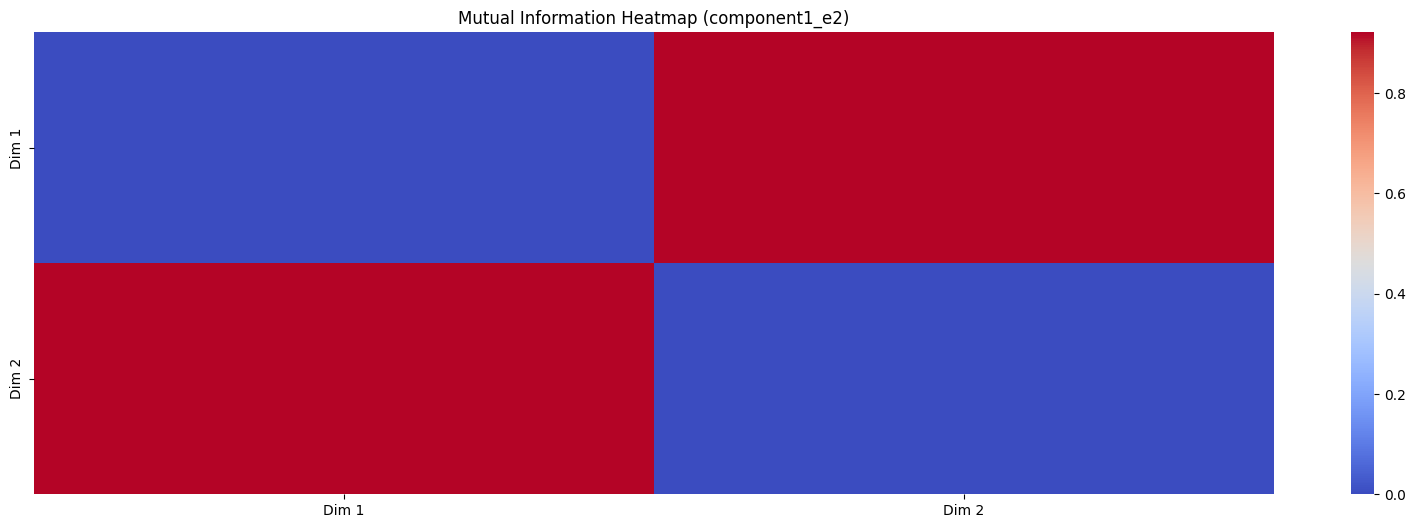

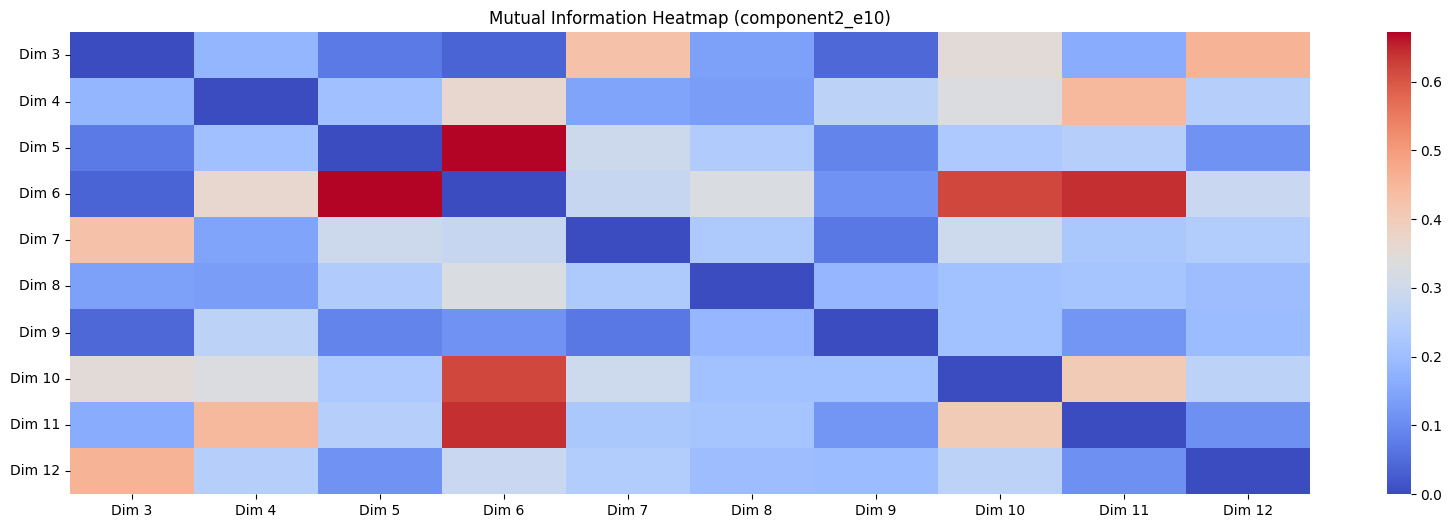

In [41]:
# === Load your data ===
comp1 = adata.obsm["component1_e2"]      # shape (7212, 2)
comp2 = adata.obsm["component2_e10"]     # shape (7212, 10)

# === Compute MI ===
mi_comp1 = mutual_information_matrix(comp1)
mi_comp2 = mutual_information_matrix(comp2)

# === Plot ===
plot_mi_matrix(mi_comp1, "Mutual Information Heatmap (component1_e2)")
plot_mi_matrix(mi_comp2, "Mutual Information Heatmap (component2_e10)", 2)

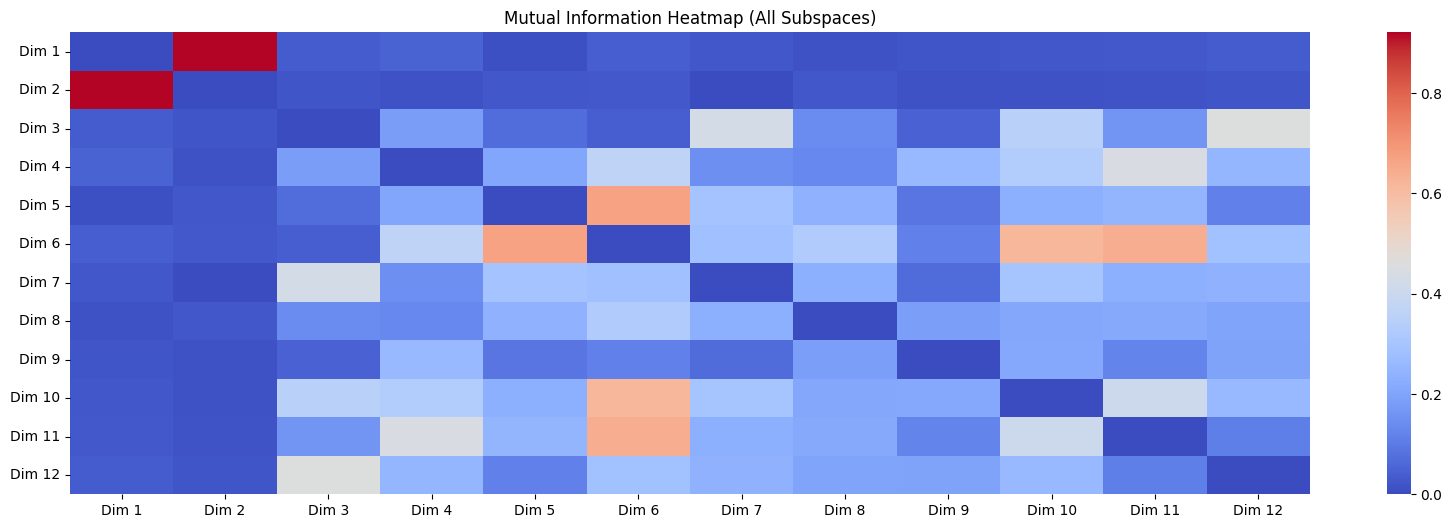

In [42]:
mi_inter = mutual_information_matrix(embeddings)
plot_mi_matrix(mi_inter, "Mutual Information Heatmap (All Subspaces)")

#### Inter-Subspace Mutual Information

**2. a) Plotting UMAPs for latent subspace cpaturing zonation**

In [ ]:
compute_umap(adata,
             l_neighbors=50,             # Q: What is this paraeter doing?
             color=['zonation1','time'],
             n_pcs=None, 
             embeddings_key="component1_e2",
             use_original_umap=False,
             palette=None,
             additional_save_information=[],
             title=None,
             save_figure=False)

**2. b) Plotting UMAPs for latent subspace cpaturing zonation**

In [ ]:
compute_umap(adata,
             l_neighbors=50,             # Q: What is this paraeter doing?
             color=['zonation1','time'],
             n_pcs=None, 
             embeddings_key="component2_e10",
             use_original_umap=False,
             palette=None,
             additional_save_information=[],
             title=None,
             save_figure=False)

In [ ]:
# 3. Experiment #1: Running CellUntangler to disentangle signals associated with fasting (the general increase in gluconeogensis across all cells), and putting all other signals in a different dimension 

- Q: What is the major list of cells that would be differentially expressed due to a liver cell 
being in a fasted state? 

In [ ]:
# 4. Implementing code to inject cell cycle signals using DRVI's boierplate code

In [ ]:
# TODOs: 
"""
1. Create a tsv demarking the genes used for zonation 


NB: 
- Might have to do QC control and remove cells with a low nCount_RNA (and perhaps do QC using `nFeature_RNA` as well) 
- Hmmm, wonder if we might need a translator that goes from one format of naming the mouse genes to another method of naming the mouse genes 
"""


# TODOs: 
1``
CellUntangler:
- First, try reproducing liver spatial and temporal separation as denoted in paper 
- Second, try running an experiment of your own 
- Third, try injecting cell cycle signals 
```